<a href="https://colab.research.google.com/github/adamzsl/unsupervised-learning/blob/main/upscaling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Resolving data files:   0%|          | 0/72 [00:00<?, ?it/s]

Dataset załadowany (streaming=True)
Pobrano 3 próbek


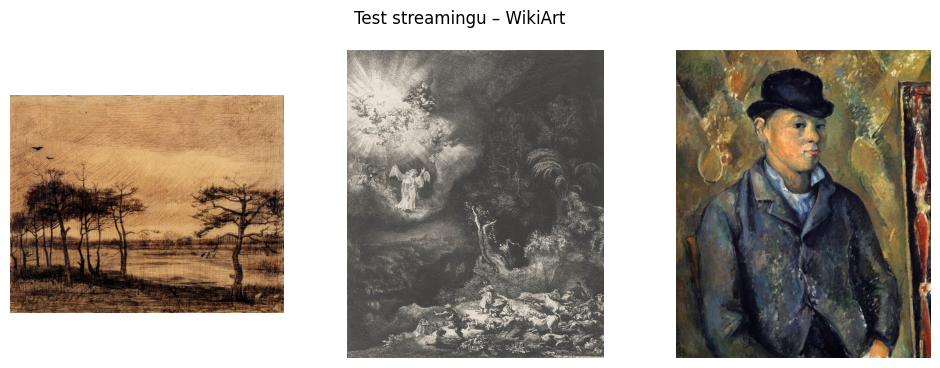

In [13]:
from datasets import load_dataset
from PIL import Image
import matplotlib.pyplot as plt

# 1️⃣ Załaduj dataset w trybie STREAMING
dataset = load_dataset(
    "huggan/wikiart",
    split="train",
    streaming=True
)

print("Dataset załadowany (streaming=True)")

# 2️⃣ Pobierz kilka pierwszych próbek
samples = []
for i, sample in enumerate(dataset):
    samples.append(sample)
    if i == 2:   # tylko 3 obrazy
        break

print(f"Pobrano {len(samples)} próbek")

# 3️⃣ Wyświetl obrazy
plt.figure(figsize=(12,4))

for i, sample in enumerate(samples):
    img = sample["image"]
    if not isinstance(img, Image.Image):
        img = Image.fromarray(img)

    plt.subplot(1, 3, i+1)
    plt.imshow(img)
    plt.axis("off")

plt.suptitle("Test streamingu – WikiArt")
plt.show()


In [14]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, IterableDataset
from torchvision import transforms
from torch.cuda.amp import autocast, GradScaler
from torchvision import transforms
from PIL import Image
from datasets import load_dataset
import matplotlib.pyplot as plt
import math
import random


In [25]:
class SplitIterableDataset(IterableDataset):
    def __init__(self, dataset, split="train"):
        assert split in ["train", "val", "test"]
        self.dataset = dataset
        self.split = split

    def __iter__(self):
        for i, sample in enumerate(self.dataset):
            if self.split == "train" and i % 10 < 8:
                yield sample
            elif self.split == "val" and i % 10 == 8:
                yield sample
            elif self.split == "test" and i % 10 == 9:
                yield sample


In [15]:
#skalacja

class WikiArtSRPatchDataset(IterableDataset):
    def __init__(
        self,
        hf_stream,
        hr_image_size,
        hr_patch_size,
        scale=2
    ):
        """
        hr_image_size : rozmiar obrazu po resize (np. 256 lub 512)
        hr_patch_size : rozmiar patcha HR (np. 128 lub 256)
        scale         : skala SR (zawsze 2)
        """
        self.dataset = hf_stream
        self.hr_image_size = hr_image_size
        self.hr_patch_size = hr_patch_size
        self.lr_patch_size = hr_patch_size // scale

        self.to_tensor = transforms.ToTensor()
        self.resize_hr = transforms.Resize(
            (hr_image_size, hr_image_size),
            interpolation=Image.BICUBIC
        )

    def __iter__(self):
        for sample in self.dataset:
            img = sample["image"]
            if not isinstance(img, Image.Image):
                img = Image.fromarray(img)

            # 1️⃣ Resize do docelowego HR
            img = self.resize_hr(img)

            # 2️⃣ Losowy patch HR
            x = random.randint(0, self.hr_image_size - self.hr_patch_size)
            y = random.randint(0, self.hr_image_size - self.hr_patch_size)

            hr_patch = img.crop((
                x,
                y,
                x + self.hr_patch_size,
                y + self.hr_patch_size
            ))

            # 3️⃣ Downsample → LR patch
            lr_patch = hr_patch.resize(
                (self.lr_patch_size, self.lr_patch_size),
                Image.BICUBIC
            )

            yield self.to_tensor(lr_patch), self.to_tensor(hr_patch)



In [16]:
#bez skalacji
class WikiArtSRDataset(IterableDataset):
    def __init__(self, hf_stream, hr_size=256, scale=2):
        self.dataset = hf_stream
        self.hr_size = hr_size
        self.lr_size = hr_size // scale

        self.to_tensor = transforms.ToTensor()
        self.hr_resize = transforms.Resize(
            (hr_size, hr_size), interpolation=Image.BICUBIC
        )
        self.lr_resize = transforms.Resize(
            (self.lr_size, self.lr_size), interpolation=Image.BICUBIC
        )

    def __iter__(self):
        for sample in self.dataset:
            img = sample["image"]
            if not isinstance(img, Image.Image):
                img = Image.fromarray(img)

            hr = self.hr_resize(img)
            lr = self.lr_resize(hr)

            yield self.to_tensor(lr), self.to_tensor(hr)


In [17]:
class ResidualBlock(nn.Module):
    def __init__(self, channels=64):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.BatchNorm2d(channels),
            nn.PReLU(),
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.BatchNorm2d(channels),
        )

    def forward(self, x):
        return x + self.block(x)


In [18]:
class UpsampleBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(channels, channels * 4, 3, padding=1),
            nn.PixelShuffle(2),
            nn.PReLU()
        )

    def forward(self, x):
        return self.block(x)


In [19]:
class SRResNet(nn.Module):
    def __init__(self, num_blocks=8):
        super().__init__()

        self.entry = nn.Sequential(
            nn.Conv2d(3, 64, 9, padding=4),
            nn.PReLU()
        )

        self.residuals = nn.Sequential(
            *[ResidualBlock(64) for _ in range(num_blocks)]
        )

        self.mid = nn.Sequential(
            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64)
        )

        self.upsample = UpsampleBlock(64)

        self.exit = nn.Conv2d(64, 3, 9, padding=4)

    def forward(self, x):
        x1 = self.entry(x)
        x2 = self.mid(self.residuals(x1))
        x = x1 + x2
        x = self.upsample(x)
        return self.exit(x)


In [20]:
def psnr(sr, hr):
    mse = torch.mean((sr - hr) ** 2)
    return 20 * torch.log10(1.0 / torch.sqrt(mse))


In [26]:
def validate(model, loader, device):
    model.eval()
    total_psnr = 0
    steps = 0

    with torch.no_grad():
        for lr_img, hr_img in loader:
            lr_img = lr_img.to(device)
            hr_img = hr_img.to(device)

            sr_img = model(lr_img)
            total_psnr += psnr(sr_img, hr_img).item()
            steps += 1

            if steps == 20:
                break

    return total_psnr / steps


def train_sr(model, train_loader, val_loader, epochs=5, lr=1e-4):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model.to(device)

    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.L1Loss()
    scaler = GradScaler(enabled=(device == "cuda"))

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        steps = 0

        for lr_img, hr_img in train_loader:
            lr_img = lr_img.to(device)
            hr_img = hr_img.to(device)

            optimizer.zero_grad()

            with autocast(enabled=(device == "cuda")):
                sr_img = model(lr_img)
                loss = criterion(sr_img, hr_img)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            total_loss += loss.item()
            steps += 1

            if steps == 100:
                break

        val_psnr = validate(model, val_loader, device)

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"L1: {total_loss/steps:.4f} | "
            f"VAL PSNR: {val_psnr:.2f} dB"
        )


In [21]:
def train_sr(
    model,
    dataloader,
    epochs=5,
    lr=1e-4,
    device="cuda"
):
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.L1Loss()
    scaler = GradScaler()

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        total_psnr = 0
        steps = 0

        for lr_img, hr_img in dataloader:
            lr_img = lr_img.to(device)
            hr_img = hr_img.to(device)

            optimizer.zero_grad()

            with autocast():
                sr_img = model(lr_img)
                loss = criterion(sr_img, hr_img)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            total_loss += loss.item()
            total_psnr += psnr(sr_img, hr_img).item()
            steps += 1

            if steps == 100:  # limit per epoch (streaming)
                break

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"L1: {total_loss/steps:.4f} | "
            f"PSNR: {total_psnr/steps:.2f} dB"
        )


In [22]:
def visualize(model, dataset, device="cuda"):
    model.eval()
    lr_img, hr_img = next(iter(dataset))

    with torch.no_grad():
        sr_img = model(lr_img.unsqueeze(0).to(device)).cpu().squeeze(0)

    def show(img, title):
        plt.imshow(img.permute(1,2,0).clamp(0,1))
        plt.title(title)
        plt.axis("off")

    plt.figure(figsize=(12,4))
    plt.subplot(1,3,1); show(lr_img, "LR")
    plt.subplot(1,3,2); show(sr_img, "SR")
    plt.subplot(1,3,3); show(hr_img, "HR")
    plt.show()


Resolving data files:   0%|          | 0/72 [00:00<?, ?it/s]

/tmp/ipython-input-120484848.py:11: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/tmp/ipython-input-120484848.py:25: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 1/5 | L1: 0.1079 | PSNR: 17.80 dB
Epoch 2/5 | L1: 0.0618 | PSNR: 21.82 dB
Epoch 3/5 | L1: 0.0500 | PSNR: 23.34 dB
Epoch 4/5 | L1: 0.0451 | PSNR: 24.15 dB
Epoch 5/5 | L1: 0.0420 | PSNR: 24.70 dB


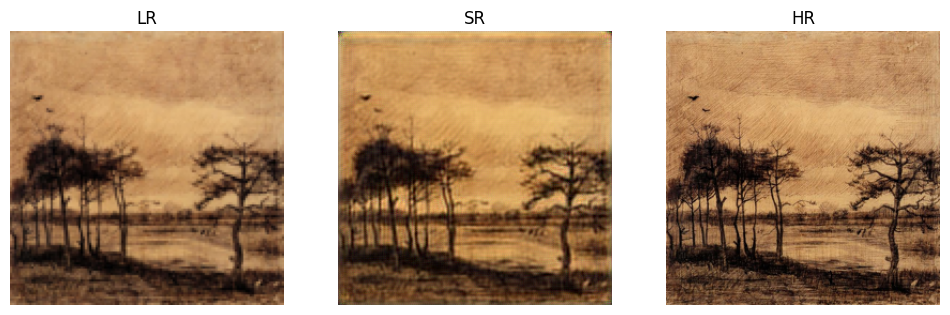

In [23]:
hf_stream = load_dataset(
    "huggan/wikiart",
    split="train",
    streaming=True
)
dataset = WikiArtSRDataset(hf_stream, hr_size=256)
loader = DataLoader(dataset, batch_size=8)

model = SRResNet()

train_sr(
    model,
    loader,
    epochs=5,        # na test
    lr=1e-4
)

visualize(model, dataset)


Resolving data files:   0%|          | 0/72 [00:00<?, ?it/s]

/tmp/ipython-input-120484848.py:11: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/tmp/ipython-input-120484848.py:25: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 1/5 | L1: 0.1018 | PSNR: 18.22 dB
Epoch 2/5 | L1: 0.0633 | PSNR: 21.52 dB
Epoch 3/5 | L1: 0.0542 | PSNR: 22.72 dB
Epoch 4/5 | L1: 0.0474 | PSNR: 23.70 dB
Epoch 5/5 | L1: 0.0459 | PSNR: 24.04 dB


'(ProtocolError('Connection aborted.', RemoteDisconnected('Remote end closed connection without response')), '(Request ID: 66d1cbce-3e68-4e73-976f-8cbe5a493b42)')' thrown while requesting GET https://huggingface.co/datasets/huggan/wikiart/resolve/d559852d2b232e0fcf195e775866964f0564f2b5/data/train-00000-of-00072.parquet
Retrying in 1s [Retry 1/5].


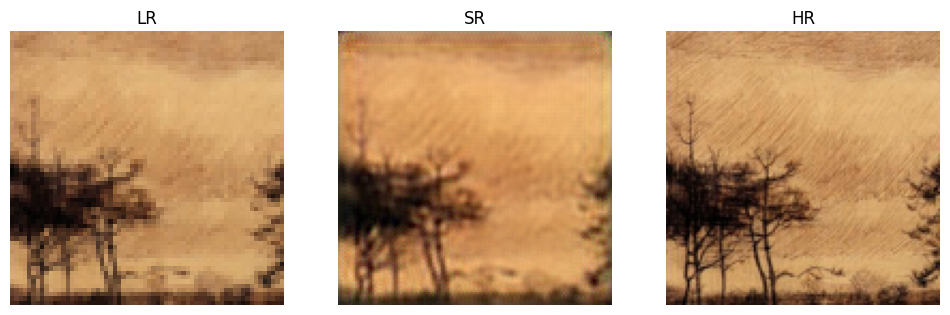

In [24]:
from datasets import load_dataset
from torch.utils.data import DataLoader

# 1️⃣ Streaming z Hugging Face
hf_stream = load_dataset(
    "huggan/wikiart",
    split="train",
    streaming=True
)

# 2️⃣ PATCH-BASED dataset
dataset = WikiArtSRPatchDataset(
    hf_stream,
    hr_image_size=256,
    hr_patch_size=128
)

# 3️⃣ DataLoader
loader = DataLoader(
    dataset,
    batch_size=8,
    num_workers=2
)

# 4️⃣ Model
model = SRResNet()

# 5️⃣ Trening
train_sr(
    model,
    loader,
    epochs=5,   # testowo
    lr=1e-4
)

# 6️⃣ Wizualizacja (patch LR → SR → HR)
visualize(model, dataset)


Resolving data files:   0%|          | 0/72 [00:00<?, ?it/s]

/tmp/ipython-input-3308018484.py:27: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=(device == "cuda"))
/tmp/ipython-input-3308018484.py:40: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(device == "cuda")):


Epoch 1/5 | L1: 0.1034 | VAL PSNR: 21.48 dB
Epoch 2/5 | L1: 0.0614 | VAL PSNR: 22.49 dB
Epoch 3/5 | L1: 0.0527 | VAL PSNR: 23.84 dB
Epoch 4/5 | L1: 0.0474 | VAL PSNR: 24.54 dB
Epoch 5/5 | L1: 0.0460 | VAL PSNR: 24.78 dB


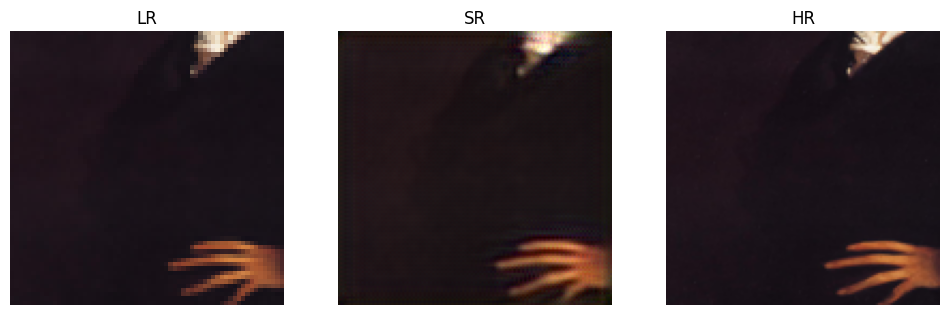

In [27]:
hf_stream = load_dataset(
    "huggan/wikiart",
    split="train",
    streaming=True
)

train_stream = SplitIterableDataset(hf_stream, "train")
val_stream   = SplitIterableDataset(hf_stream, "val")
test_stream  = SplitIterableDataset(hf_stream, "test")

train_ds = WikiArtSRPatchDataset(train_stream, 256, 128)
val_ds   = WikiArtSRPatchDataset(val_stream,   256, 128)
test_ds  = WikiArtSRPatchDataset(test_stream,  256, 128)

train_loader = DataLoader(train_ds, batch_size=8, num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=8, num_workers=2)

model = SRResNet()

train_sr(
    model,
    train_loader,
    val_loader,
    epochs=5,
    lr=1e-4
)

visualize(model, test_ds)


In [28]:
import torch
import torch.nn.functional as F

def sr_full_image(
    model,
    lr_image,          # tensor [3, H, W] w [0,1]
    scale=2,
    patch_size=128,
    overlap=32
):
    """
    Sliding-window super-resolution inference.
    """
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = model.to(device).eval()

    _, H, W = lr_image.shape
    stride = patch_size - overlap

    sr_H, sr_W = H * scale, W * scale

    output = torch.zeros(3, sr_H, sr_W, device=device)
    weight = torch.zeros(3, sr_H, sr_W, device=device)

    lr_image = lr_image.to(device)

    for y in range(0, H - patch_size + 1, stride):
        for x in range(0, W - patch_size + 1, stride):
            lr_patch = lr_image[:, y:y+patch_size, x:x+patch_size].unsqueeze(0)

            with torch.no_grad():
                sr_patch = model(lr_patch).squeeze(0)

            y_sr = y * scale
            x_sr = x * scale

            output[:, y_sr:y_sr+patch_size*scale, x_sr:x_sr+patch_size*scale] += sr_patch
            weight[:, y_sr:y_sr+patch_size*scale, x_sr:x_sr+patch_size*scale] += 1

    return (output / weight).clamp(0, 1).cpu()


In [29]:
from torchvision.transforms import ToTensor, Resize

# 1️⃣ weź próbkę z test setu (PEŁNY obraz)
sample = next(iter(test_stream))
img = sample["image"]

# 2️⃣ przygotuj LR
hr_full = Resize((256, 256))(img)
lr_full = Resize((128, 128))(hr_full)

lr_tensor = ToTensor()(lr_full)

# 3️⃣ inferencja CAŁEGO obrazu
sr_full = sr_full_image(
    model,
    lr_tensor,
    patch_size=64,   # zgodne z treningiem
    overlap=16
)


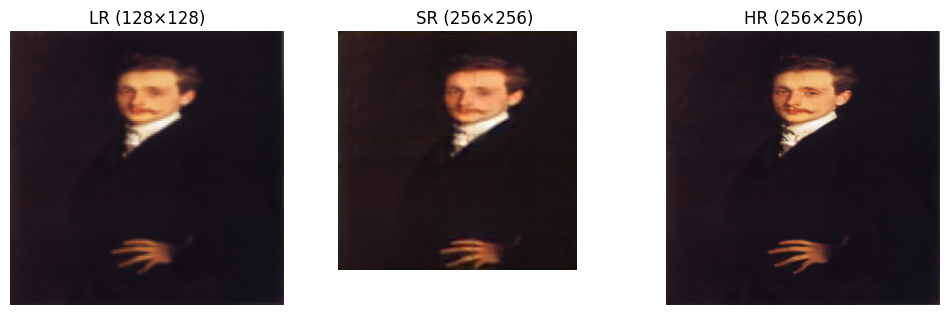

In [30]:
import matplotlib.pyplot as plt

def show(img, title):
    plt.imshow(img.permute(1,2,0))
    plt.title(title)
    plt.axis("off")

plt.figure(figsize=(12,4))
plt.subplot(1,3,1); show(ToTensor()(lr_full), "LR (128×128)")
plt.subplot(1,3,2); show(sr_full, "SR (256×256)")
plt.subplot(1,3,3); show(ToTensor()(hr_full), "HR (256×256)")
plt.show()
